In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np


In [2]:
# Load and preprocess CIFAR10 dataset
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

# Normalize pixel values to [0, 1]
train_images = train_images.astype('float32') / 255.0
test_images = test_images.astype('float32') / 255.0


c:\Users\xinod\Documents\Projects\CEC616\.venv\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


In [3]:
# Convert labels to one-hot encoding
train_labels = tf.keras.utils.to_categorical(train_labels, 10)
test_labels = tf.keras.utils.to_categorical(test_labels, 10)


In [4]:
# Create validation split (10% of training data)
# Shuffle before splitting to make training and validation distributions similar

indices = np.arange(len(train_images))
np.random.shuffle(indices)

train_images = train_images[indices]
train_labels = train_labels[indices]

val_split = 0.1
val_samples = int(len(train_images) * val_split)

val_images, val_labels = train_images[:val_samples], train_labels[:val_samples]
train_images, train_labels = train_images[val_samples:], train_labels[val_samples:]


In [5]:
# Data augmentation layer to reduce overfitting
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

# Build CNN model
model = models.Sequential([
    data_augmentation,

    layers.Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.30),

    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.35),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.40),
    layers.Dense(10, activation='softmax')
])


c:\Users\xinod\Documents\Projects\CEC616\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
# Compile model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [7]:
# Define callbacks
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=8,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ModelCheckpoint(
        filepath='best_model_cifar10.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=4,
        min_lr=1e-6,
        verbose=1
    ),

    tf.keras.callbacks.CSVLogger(
        'training_log.csv',
        append=False
    )
]


In [8]:
# Train model
history = model.fit(
    train_images,
    train_labels,
    epochs=50,
    batch_size=64,
    validation_data=(val_images, val_labels),
    callbacks=callbacks,
    shuffle=True
)


Epoch 1/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 0s 361ms/step - accuracy: 0.2802 - loss: 2.1597
Epoch 1: val_accuracy improved from None to 0.44440, saving model to best_model_cifar10.keras

Epoch 1: finished saving model to best_model_cifar10.keras
704/704 ━━━━━━━━━━━━━━━━━━━━ 271s 370ms/step - accuracy: 0.3415 - loss: 1.8419 - val_accuracy: 0.4444 - val_loss: 1.7547 - learning_rate: 5.0000e-04
Epoch 2/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 0s 282ms/step - accuracy: 0.4381 - loss: 1.5580
Epoch 2: val_accuracy improved from 0.44440 to 0.49820, saving model to best_model_cifar10.keras

Epoch 2: finished saving model to best_model_cifar10.keras
704/704 ━━━━━━━━━━━━━━━━━━━━ 204s 289ms/step - accuracy: 0.4548 - loss: 1.5208 - val_accuracy: 0.4982 - val_loss: 1.5675 - learning_rate: 5.0000e-04
Epoch 3/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step - accuracy: 0.4937 - loss: 1.4147
Epoch 3: val_accuracy improved from 0.49820 to 0.54620, saving model to best_model_cifar10.keras

Epoch 3: finished saving mode

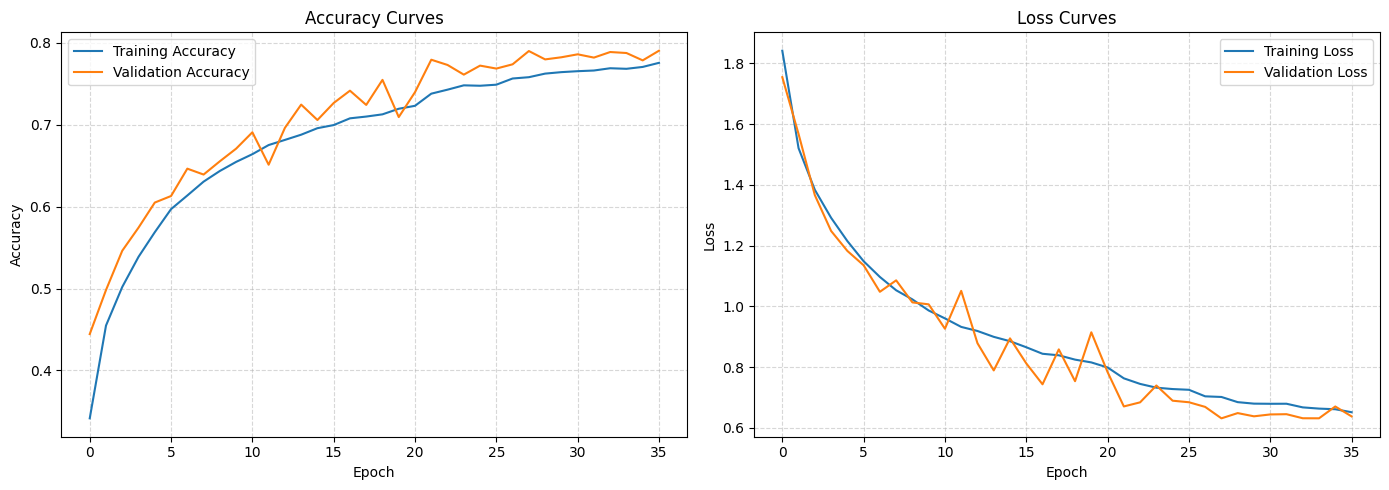

In [9]:
# Plot training history
def plot_history(history):
    plt.figure(figsize=(14, 5))
    
    # Accuracy plot
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Accuracy Curves')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(linestyle='--', alpha=0.5)
    
    # Loss plot
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Loss Curves')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.savefig('training_history.png', dpi=300)
    plt.show()

plot_history(history)


In [10]:
# Evaluate on test set
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=0)
print(f'\nTest accuracy: {test_acc:.4f}, Test loss: {test_loss:.4f}')

# Optional: Save final model
model.save('cifar10_cnn_final.keras')


Test accuracy: 0.7837, Test loss: 0.6371


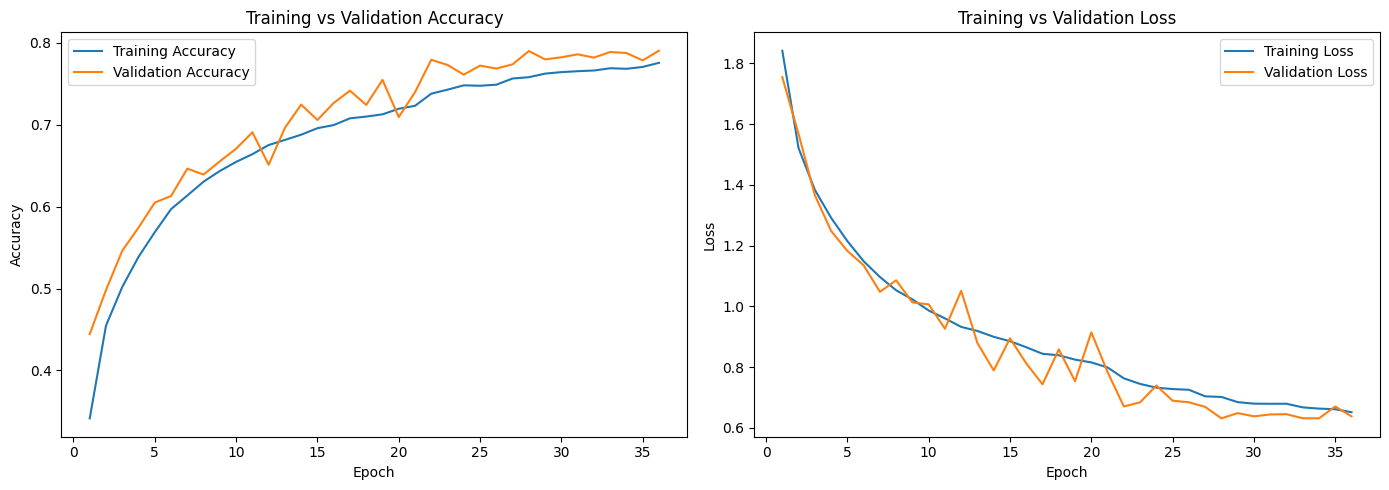

In [11]:
# Plot training and validation curves

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(14, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.tight_layout()
plt.show()
